In [105]:
import os 
import optuna
import logging
import random
import datetime

import pandas as pd 
import numpy as np 
import yfinance as yf 
import seaborn as sns
import matplotlib.pyplot as plt 
import scipy.cluster.hierarchy as sch 
import tensorflow as tf 
from tensorflow import keras #type: ignore 
from keras import layers
from scipy.spatial.distance import pdist 
from sklearn.preprocessing import StandardScaler
from arch import arch_model 

DATA_FINAL = datetime.datetime.now().strftime('2026-04-10')
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- Configuração do modelo --- 
seed_value = 42 
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

CAPITAL_DISPONIVEL = 1_000_000

# --- Carregamento e tratamento dos dados ---

etfs_dict = {
    'Emergents': ['IEMG'],
    'Energy': ['XLE'],
    'Defense': ['ITA'],
    'Tech': ['VGT'],
    'Small Caps': ['VBR'],
    'International': ['EXUS'],
    'Gold': ['IAU'],
    'Alternatives': ['DBMF']
}

all_etfs = [item for sublist in etfs_dict.values() for item in sublist]

raw_data = yf.download(all_etfs, start='1998-12-16', end=DATA_FINAL, auto_adjust=True) 

#Tempo de 10-11 anos para, além de garantir a alta liquide.z, 
#analisa-se e surfa diversos períodos e ciclos econômicos

close_df = raw_data['Close'].copy().ffill()
close_df = close_df.dropna(how='all')

volume_df = raw_data['Volume'].copy().ffill()

valid_etfs = []
MIN_DAYS_HISTORY = 252 

#Para uma aplicação correta do HRP, aplica-se um filtro de pelo menos 1 ano útil de negociações.
# Sua utilização se deve, pois nem todas as empresas podem estar listadas desde o período inicial de dados. 

MIN_ADTV = 10_000_000

for t in all_etfs:
    if t not in close_df.columns or t not in volume_df.columns:
        continue
    if close_df[t].dropna().shape[0] < MIN_DAYS_HISTORY:
        print(f'ETF {t} foi rejeitado: Histórico de tempo muito curto')
        continue

    precos_recentes = close_df[t].iloc[-21:]
    volumes_recentes = volume_df[t].iloc[-21:]

    adtv_21 = (precos_recentes * volumes_recentes).mean()
    
    if not t.endswith('=X'): # Ignora moedas, que não têm volume padrão
        if pd.isna(adtv_21) or adtv_21 < MIN_ADTV:
            print(f'ETF {t} rejeitado: Baixa Liquidez (Calculado: {adtv_21})')
            continue
            
    valid_etfs.append(t)

print(f"ETFs validados: {valid_etfs}")

clean_close = close_df[valid_etfs].copy()
clean_ret_log = np.log(clean_close/clean_close.shift(1))

for t in valid_etfs:
    media = clean_ret_log[t].mean()
    desvio = clean_ret_log[t].std()
    limite_superior = media + (4 * desvio)
    limite_inferior = media - (4 * desvio)

    clean_ret_log[t] = clean_ret_log[t].clip(lower=limite_inferior, upper=limite_superior)
print('Coleta e Análise de Dados do Portfólio Concluída')

[*********************100%***********************]  8 of 8 completed

ETF EXUS foi rejeitado: Histórico de tempo muito curto
ETFs validados: ['IEMG', 'XLE', 'ITA', 'VGT', 'VBR', 'IAU', 'DBMF']
Coleta e Análise de Dados do Portfólio Concluída


In [106]:
# --- Configurações do Modelo E-GARCH --- 
egarch_volatility = pd.DataFrame()

#Usando valid_etfS e clean_ret_log para cálculo e previsão da volatilidade:
for t in valid_etfs: 
    try: 
        returns = 100 * clean_ret_log[t].dropna()
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
        res = am.fit(update_freq=5, disp='off')
        egarch_volatility[t] = res.conditional_volatility / 100
    except: continue

egarch_volatility = egarch_volatility.dropna()
egarch_volatility

,IEMG,XLE,ITA,VGT,VBR,IAU,DBMF
Date,,,,,,,
2019-05-09,0.011852,0.012310,0.010957,0.010082,0.010160,0.006030,0.006023
2019-05-10,0.013153,0.011750,0.010452,0.010460,0.009914,0.006005,0.005563
2019-05-13,0.012500,0.011363,0.010028,0.009982,0.009467,0.005872,0.005155
2019-05-14,0.016166,0.012523,0.013245,0.015571,0.012832,0.006304,0.005630
2019-05-15,0.015436,0.012364,0.012744,0.014956,0.012295,0.006168,0.005898
...,...,...,...,...,...,...,...
2026-04-02,0.017499,0.015278,0.019340,0.018479,0.012433,0.021719,0.007832
2026-04-06,0.017375,0.014673,0.019093,0.017412,0.011786,0.021508,0.007483
2026-04-07,0.016348,0.014197,0.018236,0.016372,0.011217,0.020595,0.007308


In [107]:
# --- Features --- 
# A função .tz_localize vai remover a diferença de fuso entre os dados.

print("Baixando os dados OHLCV para os indicadores técnicos do modelo")

ohlcv = yf.download(valid_etfs, start='1998-12-16', end=DATA_FINAL, auto_adjust=True)
ohlcv.index = ohlcv.index.tz_localize(None)
clean_close.index = clean_close.index.tz_localize(None)

print("Baixando Leading Indicators Globais (VIX e Juros 10A)...")
macro_tickers = ['^VIX', '^TNX']
macro_data = yf.download(macro_tickers, start='2015-01-01', end=DATA_FINAL, auto_adjust=True)['Close']
macro_data = macro_data.ffill()
macro_data.index = macro_data.index.tz_localize(None) # Removendo fuso
macro_data['VIX_Change'] = np.log(macro_data['^VIX'] / macro_data['^VIX'].shift(1)) 
macro_data['TNX_Change'] = macro_data['^TNX'].diff()

print("Baixando Benchmark para Performance Relativa...")
benchmark = yf.download('IVV', start='1998-12-16', end=DATA_FINAL, auto_adjust=True)['Close']
benchmark = benchmark.ffill()
benchmark.index = benchmark.index.tz_localize(None)

panel = []
print("Construindo Painel Neural com Sistema de Pontuação...")

for t in valid_etfs:
    try: 
        if t not in egarch_volatility.columns: continue

        df = clean_close[[t]].copy()
        df.columns = ['Close']
        df = df.dropna()
        df['ticker'] = t

        # --- 1. DADOS EXTRAS PARA INDICADORES ---
        df['ret_log'] = clean_ret_log[t]
        df['High'] = ohlcv['High'][t]
        df['Low'] = ohlcv['Low'][t]
        df['Volume'] = ohlcv['Volume'][t]

        # --- 2. CÁLCULO DOS INDICADORES TÉCNICOS ---
        # RSI (14 days)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-8)
        df['RSI'] = 100 - (100 / (1 + rs))

        # EMAs e MAs
        df['EMA_9'] = df['Close'].ewm(span=9, adjust=False).mean()
        df['EMA_21'] = df['Close'].ewm(span=21, adjust=False).mean()
        df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
        df['MA_50'] = df['Close'].rolling(window=50).mean()

        # MACD
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_hist'] = df['MACD'] - df['MACD_signal']

        # Volume Ratio e Momentum
        df['Volume_ratio'] = df['Volume'] / (df['Volume'].rolling(window=20).mean() + 1e-8)
        df['Price_momentum_1d'] = df['Close'].pct_change() # 24h momentum adaptado para diário

        # Estocástico (Stoch_K)
        low_14 = df['Low'].rolling(window=14).min()
        high_14 = df['High'].rolling(window=14).max()
        df['Stoch_K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14 + 1e-8))
        """
        # Performance Relativa
        df['Relative_Ratio'] = df['ret_log'] - benchmark_ret_log
        df['Rel_Ratio_SMA'] = df['Relative_Ratio'].rolling(window=20).mean()
        df.loc[df['Relative_Ratio'] > df['Rel_Ratio_SMA'], 'points_buy'] += 20 
        df.loc[df['Relative_Ratio'] < df['Rel_Ratio_SMA'], 'points_buy'] -= 10
        """
        # --- 3. SISTEMA DE PONTOS (A SUGESTÃO DA ORTOGONALIZAÇÃO) ---
        df['points_buy'] = 0
        
        df.loc[df['RSI'] <= 30, 'points_buy'] += 20
        df.loc[(df['RSI'] > 30) & (df['RSI'] <= 40), 'points_buy'] += 10
        df.loc[df['RSI'] > 50, 'points_buy'] += 10
        
        ema_bullish = (df['EMA_9'] > df['EMA_50']) & (df['EMA_21'] > df['EMA_50'])
        df.loc[ema_bullish, 'points_buy'] += 15
        
        df.loc[df['MACD'] > 0, 'points_buy'] += 15
        
        macd_growing = df['MACD_hist'] > df['MACD_hist'].shift(1)
        df.loc[macd_growing, 'points_buy'] += 5
        
        df.loc[df['Volume_ratio'] >= 1.5, 'points_buy'] += 15
        df.loc[df['Price_momentum_1d'] > 0.02, 'points_buy'] += 5
        df.loc[df['Stoch_K'] <= 20, 'points_buy'] += 5

        # (Bandas de Bollinger foram removidas do modelo)
        # Por que? Elas assumem que os retornos são distribuições normais,
        # o que realmente não acontece. 

        # --- 4. TRIGGER DE VENDA SIMPLIFICADO ---
        ema9_above_ma50_prev = df['EMA_9'].shift(1) > df['MA_50'].shift(1)
        ema9_below_ma50_now = df['EMA_9'] <= df['MA_50']
        # Convertendo o booleano (True/False) para número (1/0) para a IA entender
        df['sell_trigger'] = (ema9_above_ma50_prev & ema9_below_ma50_now).astype(int) 

        # --- 5. RISCO E MACRO (Blindagem do Fundo) ---
        df['egarch_vol'] = egarch_volatility[t]
        df = df.join(macro_data[['VIX_Change', 'TNX_Change']], how='inner')

        # --- 6. TARGET MACHINE LEARNING ---
        df['target_weekly'] = np.log(df['Close'].shift(-5) / df['Close'].shift(-1))
        df['rank_score'] = df['target_weekly'] / (df['egarch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except Exception as e: 
        print(f'Erro no ETF {t}: {e}')
        continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)
data['rank'] = data.groupby(data.index)['rank_score'].rank(pct=True)

# A Inteligência Artificial agora cruza o seu Sistema de Pontos com a Macroeconomia!
features = ['points_buy', 'sell_trigger', 'egarch_vol', 'VIX_Change', 'TNX_Change']

# --- PREPARAÇÃO DE DADOS (Corte Cronológico TRAIN / VAL) ---
train_data = data[data.index < '2026-01-01']
val_data = data[(data.index >= '2026-01-01') & (data.index < data.index.max())]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[features])
y_train = (train_data['rank_score'] > 0).astype(int).values
X_val = scaler.transform(val_data[features])
y_val = (val_data['rank_score'] > 0).astype(int).values



Baixando os dados OHLCV para os indicadores técnicos do modelo


[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


Baixando Leading Indicators Globais (VIX e Juros 10A)...
Baixando Benchmark para Performance Relativa...
Construindo Painel Neural com Sistema de Pontuação...


In [108]:
# --- Optuna e configuração --- 
# A função do optuna será otimizar a busca dos hiperparâmetros do modelo de previsão, mellhorando o desempenho do modelo

print("Iniciando a otimização de hiperparâmetros com Optuna")

def objective(trial):
    model = keras.Sequential()
    model.add(keras.layers.Dense(trial.suggest_int('units', 128, 256), activation='relu', input_shape=(X_train.shape[1],)))
    model.add(layers.LeakyReLU(alpha=0.05)) # A função LeakyReLU permite que a rede neural aprenda e treine com sinais negativos de mercado
    model.add(layers.Dropout(trial.suggest_float('dropout', 0.1, 0.5)))

    #A função sigmoid na saída para cuspir a probabilidade e evitar Shrinkage
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0, validation_split=0.1)

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

final_model = keras.Sequential([
    layers.Dense(study.best_params['units'], input_dim=X_train.shape[1]),
    layers.LeakyReLU(alpha=0.05), # Acompanha o modelo final
    layers.Dropout(study.best_params['dropout']),
    layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, epochs=15, batch_size=64, verbose=0)

print(f"Melhor arquitetura encontrada: {study.best_params['units']} Neurônios com {study.best_params['dropout']*100:.1f}% de Dropout.")

Iniciando a otimização de hiperparâmetros com Optuna


c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Melhor arquitetura encontrada: 129 Neurônios com 49.0% de Dropout.


In [109]:
print("\nTreinando a Super Rede com todos os dados disponíveis...")

X_all = np.vstack((X_train, X_val))
y_all = np.concatenate((y_train, y_val))

try:
    best_params = study.best_params
    print(f"Optuna funcionou. Usando: {best_params['units']} Neurônios.")
except Exception:
    print("⚠ Alerta: Optuna falhou nas tentativas. Acionando arquitetura padrão Institucional.")
    best_params = {'units': 32, 'dropout': 0.3}

# Arquitetura de avaliação
eval_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(best_params['units']),
    layers.LeakyReLU(negative_slope=0.05),
    layers.Dropout(best_params['dropout']),
    layers.Dense(1, activation='sigmoid')
])

eval_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
eval_model.fit(X_train, y_train, epochs=15, batch_size=64, verbose=0)

# Arquitetura com correção de input (Evita o UserWarning do Keras)
final_model = keras.Sequential([
    layers.Input(shape=(X_all.shape[1],)),
    layers.Dense(best_params['units']),
    layers.LeakyReLU(negative_slope=0.05), # negative_slope substitui alpha nas versões recentes
    layers.Dropout(best_params['dropout']),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# CORREÇÃO: Treinando com X_all e y_all em vez de X_train e y_train
final_model.fit(X_all, y_all, epochs=15, batch_size=64, verbose=0)

# Para avaliar, você pode checar no próprio X_all ou em um set de teste out-of-sample se houver
loss_final, acc_final = final_model.evaluate(X_all, y_all, verbose=0)
print(f"Acurácia Final no dataset completo: {acc_final*100:.2f}%")


Treinando a Super Rede com todos os dados disponíveis...
Optuna funcionou. Usando: 129 Neurônios.
Acurácia Final no dataset completo: 56.49%


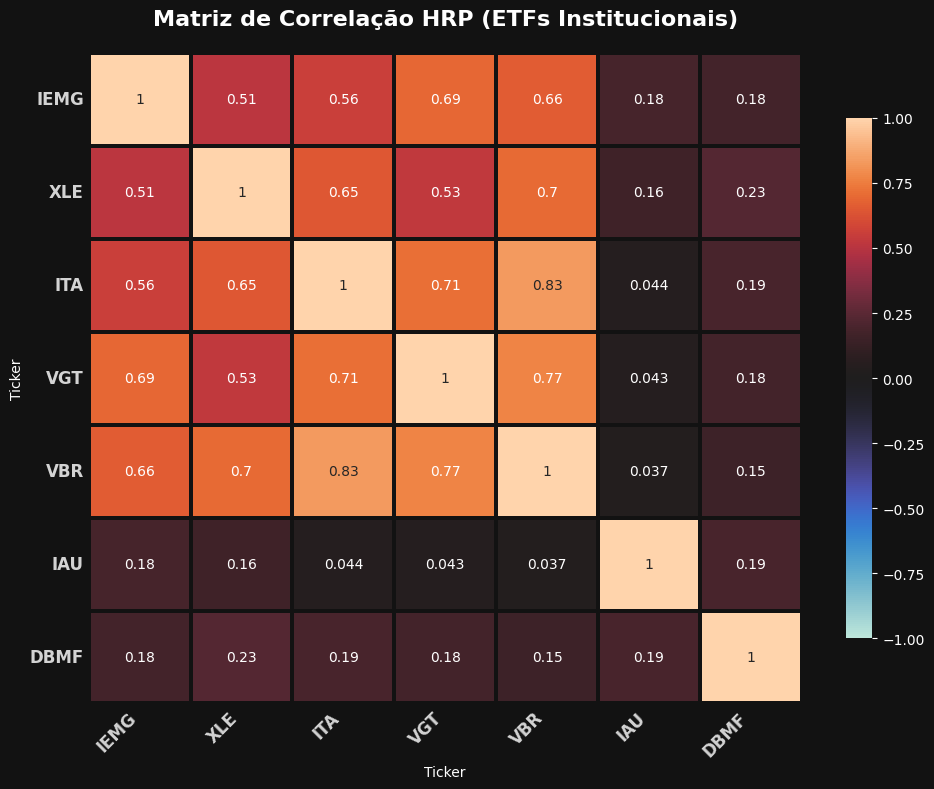

In [110]:
# --- Definindo a plotagem --- 
fig, ax = plt.subplots(figsize=(10, 8))
plt.style.use('dark_background')

bg_plot_color = '#121212' # Dark Bloomberg Theme
fig.patch.set_facecolor(bg_plot_color)
ax.set_facecolor(bg_plot_color)

# --- Correlação, Heatmap e Simulações de Monte Carlo
corr_matrix_etfs = clean_ret_log[valid_etfs].corr()
sns.heatmap(
    corr_matrix_etfs, 
    annot=True,
    #pmt = '.2f', # Para o HRP, 
    vmin=-1, vmax=1,
    center=0, 
    linewidths=1.5,
    linecolor=bg_plot_color, 
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Matriz de Correlação HRP (ETFs Institucionais)', 
             fontsize=16, 
             fontweight='bold', 
             pad=20, 
             color='white')

plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', color='lightgray')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='lightgray')

ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

In [116]:
# Aumente para 4.0 ou 5.0 se quiser concentrar ainda mais nos melhores ativos
ALPHA_POWER = 3.5 

# 2. FUNÇÃO DE RISCO DE QUEDA (DOWNSIDE DEVIATION)
# Só punimos o ativo se ele cair. Se ele subir muito, o modelo ignora o 'risco'.
def calculate_downside_risk(returns_series):
    # Considera apenas retornos abaixo de zero
    negative_returns = returns_series[returns_series < 0]
    if len(negative_returns) < 2: return 0.01
    return negative_returns.std() * np.sqrt(252) # Anualizado

# 3. CÁLCULO DA EFICIÊNCIA (O "Custo-Benefício" do Ativo)
efficiency_scores = {}
print("🚀 Calculando Relação Retorno/Risco para Máximo Rendimento:")

for ticker in valid_etfs:
    # O Alpha é o score da IA (Potencial de subida)
    ai_alpha = pred_probs_dict[ticker]
    
    # O Risco é apenas a volatilidade negativa
    risk_penalty = calculate_downside_risk(clean_ret_log[ticker])
    
    # EFICIÊNCIA = (Alpha elevado ao poder) / Risco
    # O poder exponencial 'estica' a diferença entre um ativo bom e um excelente
    score = (ai_alpha ** ALPHA_POWER) / (risk_penalty + 1e-6)
    efficiency_scores[ticker] = score
    
    print(f"{ticker:4} | Score IA: {ai_alpha:.4f} | Risco Queda: {risk_penalty*100:5.2f}% | Eficiência: {score:.2f}")

# 4. ALOCAÇÃO FINAL (Ponderação por Eficiência)
# Aqui a alocação deixa de ser igualitária. Quem é eficiente ganha a pizza.
eff_series = pd.Series(efficiency_scores)
weights = eff_series / eff_series.sum()

# 5. TRAVAS DE SEGURANÇA (Opcional - Limite de Concentração)
# Para evitar que a IA coloque 100% em um só ativo, limitamos a 50% por ativo.
weights = weights.clip(upper=0.50)
weights /= weights.sum()

print("\n💰 --- CARTEIRA DE MÁXIMA EFICIÊNCIA (YIELD TARGET) ---")
for ticker, weight in weights.sort_values(ascending=False).items():
    print(f"{ticker}: {weight*100:.2f}%")

🚀 Calculando Relação Retorno/Risco para Máximo Rendimento:
IEMG | Score IA: 0.5847 | Risco Queda: 12.93% | Eficiência: 1.18
XLE  | Score IA: 0.5719 | Risco Queda: 19.38% | Eficiência: 0.73
ITA  | Score IA: 0.5959 | Risco Queda: 15.85% | Eficiência: 1.03
VGT  | Score IA: 0.5986 | Risco Queda: 16.49% | Eficiência: 1.01
VBR  | Score IA: 0.5654 | Risco Queda: 15.98% | Eficiência: 0.85
IAU  | Score IA: 0.5971 | Risco Queda: 12.82% | Eficiência: 1.28
DBMF | Score IA: 0.5485 | Risco Queda:  9.50% | Eficiência: 1.29

💰 --- CARTEIRA DE MÁXIMA EFICIÊNCIA (YIELD TARGET) ---
DBMF: 17.45%
IAU: 17.42%
IEMG: 16.04%
ITA: 13.98%
VGT: 13.66%
VBR: 11.54%
XLE: 9.91%


In [111]:
# --- Aplicação do Modelo HES (Hierarchical Expected Shortfall) --- 

def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >=num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index; j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0])
        sort_ix = sort_ix.sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()
def get_cluster_es(returns_hist, c_items, conf=0.05):
    """
    Calcula o Expected Shortfall (CVaR) de um ramo da árvore.
    Em vez de usar matriz de covariância, usamos os retornos históricos reais.
    """
    # Isola o histórico de retornos apenas dos ETFs deste galho
    cluster_returns = returns_hist.iloc[:, c_items]
    
    # Passo A: Calcula o ES individual de cada ETF no galho
    es_individual = cluster_returns.apply(lambda x: -x[x <= x.quantile(conf)].mean())
    
    # Passo B: Define um peso provisório inversamente proporcional ao ES
    w_ = 1.0 / (es_individual + 1e-8) # 1e-8 evita divisão por zero se não houver risco
    w_ /= w_.sum()
    
    # Passo C: Simula o retorno diário deste "mini-portfólio" agrupado
    mini_port_returns = cluster_returns.dot(w_)
    
    # Passo D: Calcula o Expected Shortfall final do grupo inteiro
    threshold = mini_port_returns.quantile(conf)
    cluster_es = -mini_port_returns[mini_port_returns <= threshold].mean()
    
    return max(cluster_es, 1e-8) # Garante que sempre retornará um risco positivo

def get_rec_bipart_hes(returns_hist, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]
            c_items1 = c_items[i + 1]
            
            # Avalia a dor (Crash) do galho esquerdo e do direito
            c_es0 = get_cluster_es(returns_hist, c_items0)
            c_es1 = get_cluster_es(returns_hist, c_items1)
            
            # O capital é alocado favorecendo o galho que cai menos nos piores dias
            alpha = 1 - c_es0 / (c_es0 + c_es1)
            
            w[c_items0] *= alpha
            w[c_items1] *= 1 - alpha
    return w

def get_hes_weights(tickers, returns_hist):
    """
    Gera a alocação estrutural baseada em Hierarchical Expected Shortfall.
    """
    # A correlação ainda é usada apenas para definir QUEM é parecido com QUEM
    corr = returns_hist[tickers].corr()
    dist = np.sqrt(0.5 * (1 - corr))
    link = sch.linkage(pdist(dist), method='ward')
    sort_ix = get_quasi_diag(link)
    
    # A divisão do dinheiro recebe o histórico de retornos, não a covariância
    w = get_rec_bipart_hes(returns_hist[tickers], sort_ix)
    w.index = returns_hist[tickers].columns[sort_ix]
    return w

def weights_bounds(weights_series, min_weight=0.05, max_weight=0.30):
    bound_weights = weights_series.clip(lower=min_weight, upper=max_weight)
    final_weights = bound_weights / bound_weights.sum()
    
    return final_weights

base_hes_weights = get_hes_weights(valid_etfs, clean_ret_log)

pred_probs_dict = {}
print("🧠 AI Model Scores (Previsões baseadas no último dia válido):")

for ticker in valid_etfs:
    # Isola o histórico apenas deste ativo (usando o df 'data' da Célula 2)
    df_ticker = data[data['ticker'] == ticker]
    
    if df_ticker.empty:
        pred_probs_dict[ticker] = 0.50 # Se der erro no dado, fica neutro por segurança
        continue
        
    # Extrai as features EXATAMENTE do último dia disponível
    latest_features = df_ticker.iloc[-1:][features]
    
    # Aplica o scaler que foi treinado lá na Célula 2 para o formato ficar correto
    latest_features_scaled = scaler.transform(latest_features)
    
    # Pede para a Rede Neural prever o futuro (retorna a probabilidade [0 a 1])
    score = final_model.predict(latest_features_scaled, verbose=0)[0][0]
    
    pred_probs_dict[ticker] = float(score)
    print(f"{ticker}: {score:.4f}")

# ====================================================================

base_hes_weights = get_hes_weights(valid_etfs, clean_ret_log)

MAX_TILT_LIMIT = 0.30
final_weights = {}

for ticker in valid_etfs:
    base_weight = base_hes_weights[ticker]
    ai_score = pred_probs_dict[ticker]
    
    # Transforma o Score [0 a 1] em Sentimento [-1 a 1]
    sentiment = (ai_score - 0.5) * 2
    
    # Aplica o multiplicador da IA sobre a base estrutural do HES
    multiplier = 1 + (sentiment * MAX_TILT_LIMIT)
    tilted_weight = max(0.0001, base_weight * multiplier)
    
    final_weights[ticker] = tilted_weight

weights_series = pd.Series(final_weights)
normalized_weights = weights_series / weights_series.sum()

print("\n🛡️🎯 Final HES + Smart Tilting Allocation ---")
for ticker, weight in normalized_weights.items():
    print(f"{ticker}: {weight*100:.2f}%")

🧠 AI Model Scores (Previsões baseadas no último dia válido):
IEMG: 0.5847
XLE: 0.5719
ITA: 0.5959
VGT: 0.5986
VBR: 0.5654
IAU: 0.5971
DBMF: 0.5485

🛡️🎯 Final HES + Smart Tilting Allocation ---
IEMG: 13.27%
XLE: 16.08%
ITA: 10.31%
VGT: 10.78%
VBR: 10.07%
IAU: 16.77%
DBMF: 22.71%


In [117]:
# --- Inferência: Forecast para a próxima semana ---
from scipy.stats import norm
from scipy.spatial.distance import squareform

print("\nRodando Forecast (Filtro de Kalman + HRP com Cópulas) para a próxima semana...")

latest_date = data.index.max()
latest_data = data.groupby('ticker').tail(1).copy()

X_latest = scaler.transform(latest_data[features])

# =========================================================================
ia = []
for _ in range(10):
    chute = final_model(X_latest, training=True).numpy().flatten()
    ia.append(chute)

raw_preds = np.mean(ia, axis=0)

Q_noise, R_noise = 0.02, 0.10
smoothed_preds = []

for z in raw_preds:
    x_prior, P_prior = 0.5, 1.0 + Q_noise
    K = P_prior / (P_prior + R_noise)
    x_post = x_prior + K * (z - x_prior)
    smoothed_preds.append(x_post)

latest_data['pred_score'] = smoothed_preds

# === Aplicando o Fitro === 

limiar = latest_data['pred_score'].quantile(0.80)
candidates = latest_data[latest_data['pred_score'] > limiar]
selected_tickers = candidates['ticker'].tolist()

if len(selected_tickers) < 2:
    print(f"\n=> ALERTA: Modelo indica Risco Extremo. Recomendação: Manter 100% em Caixa (R$ {CAPITAL_DISPONIVEL:.2f}).")
else:
    past_rets = data[(data.index <= latest_date) & (data.index >= latest_date - pd.Timedelta(days=180))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret_log')
    
    # =====================================================================
    # --- MÓDULO DE CÓPULAS GAUSSIANAS (Substitui a Correlação Linear) ---
    # =====================================================================
    # 1. Transforma os retornos em Marginais Uniformes 
    uniform_marginals = past_rets_pivot[selected_tickers].rank(pct=True)
    
    # 2. Trava de Segurança: Evita limites absolutos 0 e 1 (infinito na CDF inversa)
    uniform_marginals = uniform_marginals.clip(lower=1e-4, upper=1-1e-4)
    
    # 3. Mapeamento para o Domínio Gaussiano (Inversa da CDF Normal: Z = Φ⁻¹(U))
    gaussian_marginals = pd.DataFrame(
        norm.ppf(uniform_marginals), 
        index=uniform_marginals.index, 
        columns=uniform_marginals.columns
    )
    
    # 4. Matriz de Dependência da Cópula (Muito mais robusta contra Cisnes Negros)
    copula_corr = gaussian_marginals.corr().fillna(0)
    # =====================================================================
    
    current_risk = candidates.set_index('ticker')['egarch_vol'].clip(lower=0.005)
    vol_diag = np.diag(current_risk.loc[selected_tickers].values)
    
    # Matriz Forward Looking agora usa a Cópula em vez da correlação de Pearson
    forward_cov = pd.DataFrame(
        np.dot(vol_diag, np.dot(copula_corr.values, vol_diag)), 
        index=selected_tickers, columns=selected_tickers
    )
    
    # A Distância Topológica baseada na Cópula
    dist = np.sqrt(0.5 * (1 - copula_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    
    sort_ix = get_quasi_diag(linkage)
    hrp_weights_raw = get_rec_bipart_hes(forward_cov, sort_ix)
    
    weights = pd.Series(hrp_weights_raw.values, index=[selected_tickers[i] for i in hrp_weights_raw.index])
    
    # === 3. CONCENTRAÇÃO AGRESSIVA (Alinhado com o Backtest em 50%) ===
    weights = weights.clip(upper=0.05)
    weights /= weights.sum()
    
    print(f"\n=======================================================")
    print(f" Execução: PRÓXIMA SEMANA ")
    print(f"=======================================================")
    print(f"Capital Alocado: R$ {CAPITAL_DISPONIVEL:,.2f}\n")
    print(f"{'Ativo':<12} | {'Sinal IA':<10} | {'Risco GARCH':<12} | {'Alocação (%)':<15} | {'R$ Comprar'}")
    print("-" * 75)
    
    for t in selected_tickers:
        w = weights[t]
        sinal = candidates[candidates['ticker'] == t]['pred_score'].values[0]
        risco = current_risk[t] * 100 
        valor = w * CAPITAL_DISPONIVEL
        print(f"{t:<12} | {sinal:.4f}   | {risco:8.2f}%   | {w*100:10.2f}%    | R$ {valor:,.2f}")
    
    print("=======================================================")
    print("O Modelo usou Cópulas Gaussianas para mitigar falhas da correlação linear.")


Rodando Forecast (Filtro de Kalman + HRP com Cópulas) para a próxima semana...

 Execução: PRÓXIMA SEMANA 
Capital Alocado: R$ 1,000,000.00

Ativo        | Sinal IA   | Risco GARCH  | Alocação (%)    | R$ Comprar
---------------------------------------------------------------------------
VGT          | 0.5873   |     1.96%   |      50.00%    | R$ 500,000.00
IAU          | 0.5923   |     2.17%   |      50.00%    | R$ 500,000.00
O Modelo usou Cópulas Gaussianas para mitigar falhas da correlação linear.


In [113]:
# --- Análise de Confiança do Modelo ---
print("\n=======================================================")
print("Análise das Métricas de Confiança do Modelo")
print("=======================================================")

val_preds = final_model.predict(X_val, verbose=0).flatten()
eval_df = val_data.copy() #type:ignore 
eval_df['previsao_ia'] = val_preds

limiar_compra = eval_df['previsao_ia'].quantile(0.80) 
eval_df['sinal_compra'] = eval_df['previsao_ia'] > limiar_compra
eval_df['mercado_subiu'] = eval_df['target_weekly'] > 0

TP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == True)])
FP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == False)])
FN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == True)])
TN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == False)])

accuracy = (TP + TN) / len(eval_df) if len(eval_df) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
ic = eval_df['previsao_ia'].corr(eval_df['rank'], method='spearman')

print(f"-> Verdadeiros Positivos (TP) : {TP}")
print(f"-> Falsos Positivos (FP)      : {FP}")
print(f"-> Falsos Negativos (FN)      : {FN}")
print(f"-> Verdadeiros Negativos (TN) : {TN}")
print(f"ACCURACY  (Exatidão) : {accuracy:.2%}")
print(f"PRECISION (Precisão) : {precision:.2%}")
print(f"RECALL    (Revocação): {recall:.2%}")
print(f"F1 SCORE             : {f1_score:.4f}")
print(f"INFO. COEFFICIENT    : {ic:.4f}")
print("=======================================================")


Análise das Métricas de Confiança do Modelo
-> Verdadeiros Positivos (TP) : 44
-> Falsos Positivos (FP)      : 42
-> Falsos Negativos (FN)      : 198
-> Verdadeiros Negativos (TN) : 143
ACCURACY  (Exatidão) : 43.79%
PRECISION (Precisão) : 51.16%
RECALL    (Revocação): 18.18%
F1 SCORE             : 0.2683
INFO. COEFFICIENT    : -0.0485


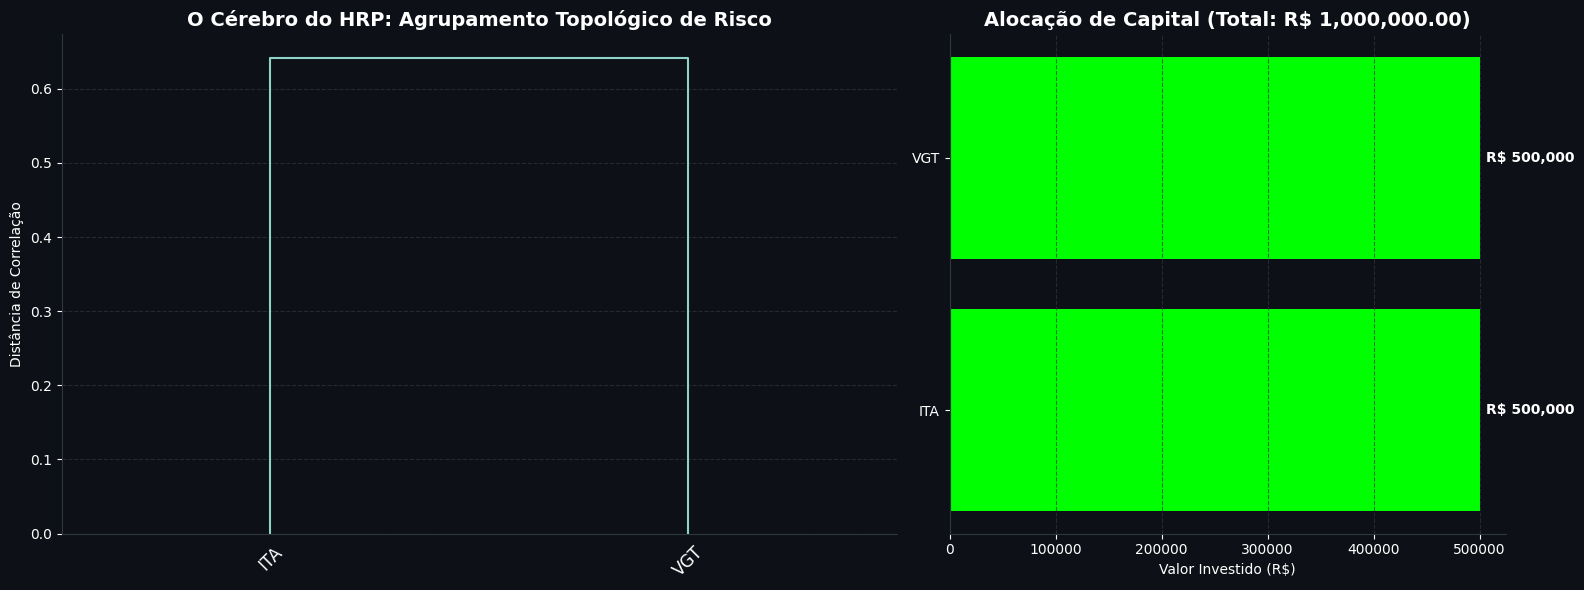

In [114]:
# --- Criação do Dashboard (Visualização Estética Bloomberg) ---
plt.style.use('dark_background')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.5, 1]})
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#0d1117')
ax2.set_facecolor('#0d1117')

sch.dendrogram(linkage, labels=selected_tickers, ax=ax1, leaf_rotation=45, leaf_font_size=12)
ax1.set_title("O Cérebro do HRP: Agrupamento Topológico de Risco", fontsize=14, fontweight='bold', color='white')
ax1.set_ylabel("Distância de Correlação", fontsize=10, color='white')
ax1.grid(axis='y', color='#30363d', linestyle='--', alpha=0.7)
ax1.tick_params(colors='white')

pesos_ordenados = weights.sort_values(ascending=True)
valores_financeiros = pesos_ordenados * CAPITAL_DISPONIVEL

bars = ax2.barh(pesos_ordenados.index, valores_financeiros.values, color='#00ff00', edgecolor='none')
ax2.set_title(f"Alocação de Capital (Total: R$ {CAPITAL_DISPONIVEL:,.2f})", fontsize=14, fontweight='bold', color='white')
ax2.set_xlabel("Valor Investido (R$)", fontsize=10, color='white')
ax2.grid(axis='x', color='#30363d', linestyle='--', alpha=0.7)
ax2.tick_params(colors='white')

for bar in bars:
    width = bar.get_width()
    ax2.annotate(f'R$ {width:,.0f}',
                 xy=(width, bar.get_y() + bar.get_height() / 2),
                 xytext=(5, 0),
                 textcoords="offset points",
                 ha='left', va='center', fontsize=10, color='white', fontweight='bold')
                 
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#30363d')
    ax.spines['bottom'].set_color('#30363d')

plt.tight_layout()
plt.show()